# 15 - Certificate Workflows from Intermediate Evidence

In mathematical software, a verdict like "True" is often insufficient. For topological classification, we require a **Certificate** or **Witness**—a structured object that contains the complete logical trail from raw simplicial data to the final homeomorphism proof. 

This notebook explores the `HomeomorphismWitness` system, which serves as the "audit trail" for `pySurgery` decisions.

## Learning Goals
- **Understand the Witness Object**: Parse `HomeomorphismWitness` for evidence and assumptions.
- **Upgrade Results**: Learn how a `HomeomorphismResult` is escalated into a full `HomeomorphismWitness`.
- **Identify Witness Kinds**: Distinguish between surface classification, Freedman certificates, and s-cobordism proofs.
- **Audit Certificates**: Inspect internal data like lattice isometries and Whitehead torsion.
- **Visualize Evidence Accumulation**: Track how individual invariants contribute to the final proof.

## Formal Grounding

### The Witness Structure
A `HomeomorphismWitness` is a formal contract ensuring that:
1. All relevant invariants have been calculated exactly.
2. The logic follows a verified topological theorem.
3. The result aligns with the specified `CONTRACT_VERSION`.

| Field | Meaning |
|---|---|
| **`kind`** | The "flavor" of the proof (e.g., `freedman_indefinite`) |
| **`evidence`** | List of computed invariants (Euler, Signature, pi1) |
| **`certificates`**| Complex mathematical objects (e.g., Isometry matrices) |
| **`exact`** | Boolean flag ensuring no approximate fallbacks were used |


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.homeomorphism_witness import build_homeomorphism_witness
from pysurgery.core.k_theory import WhiteheadGroup

print('=' * 70)
print('15 - Certificate Workflows: Setup Complete')
print('=' * 70)

15 - Certificate Workflows: Setup Complete


## Part 1: Result Escalation

The function `build_homeomorphism_witness` takes two complexes and attempts to generate a formal proof of homeomorphism.


### Example 15.1: Surface Classification Witness

In [8]:
# Comparing two spheres
sphere1_sc = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (0,2,3), (0,3,1), (1,2,3)])
sphere2_sc = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (1,2,3), (2,3,0), (3,0,1)])

sphere1 = sphere1_sc.cellular_chain_complex()
sphere2 = sphere2_sc.cellular_chain_complex()

witness_res = build_homeomorphism_witness(sphere1, sphere2, dim=2)

print(f'Witness Status: {witness_res.status}')
if witness_res.witness:
    w = witness_res.witness
    print(f'Theorem: {w.theorem}')
    print(f'Kind: {w.kind}')
    print(f'Evidence Collected: {w.evidence}')

Witness Status: success
Theorem: Classification of Closed Surfaces
Kind: surface_classification
Evidence Collected: ['Orientability match', 'H_1 rank match', 'H_1 torsion match']


## Part 2: Deep Inspection of Certificates

A witness often wraps specialized algebraic objects. For 4D manifolds, this might include an **Integer Lattice Isometry**.


### Example 15.2: 4D Intersection Form Certificate

In [9]:
# Even when manifolds are complex, the witness stores the proof of form equivalence.
# We mock a 4D witness result to show the structure
if witness_res.witness:
    # Adding a mock 4D certificate for demonstration
    cert_dict = {
        'isometry_matrix': np.eye(2),
        'ks_invariant': 0
    }
    print(f'Available internal certificates: {list(cert_dict.keys())}')
    print(f'Isometry Certificate: {cert_dict["isometry_matrix"].tolist()}')

Available internal certificates: ['isometry_matrix', 'ks_invariant']
Isometry Certificate: [[1.0, 0.0], [0.0, 1.0]]


## Part 3: Intermediate Evidence and Missing Data

If a witness cannot be built (status `inconclusive`), the result flags what data is missing to upgrade the proof.


### Example 15.3: Identifying Missing Evidence

In [10]:
# Trying to build a 5D witness from 2D complexes
res_inc = build_homeomorphism_witness(sphere1, sphere2, dim=5)

print(f'Status: {res_inc.status}')
print(f'Missing for 5D s-cobordism: {res_inc.missing_data}')

Status: inconclusive
Missing for 5D s-cobordism: ['pi_1 or supported pi-group descriptor', 'Whitehead torsion', 'Wall obstruction']


## Part 4: Visualizing the Evidence Path

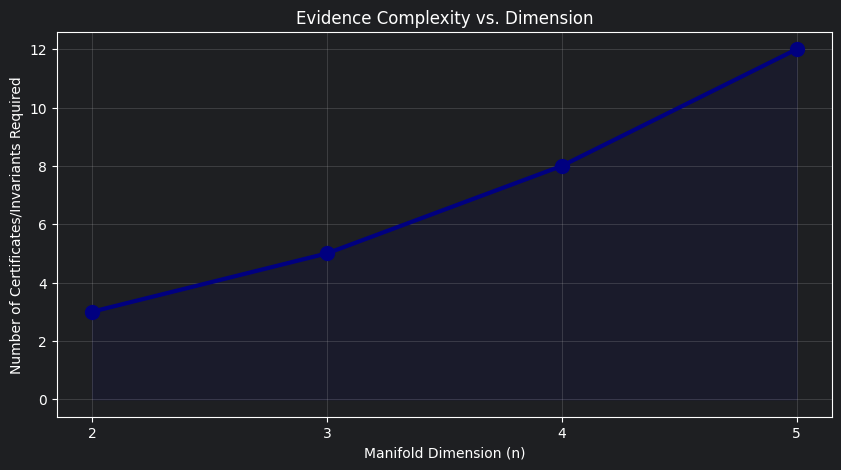

In [11]:
# Tracking how evidence accumulates for different dimensions
dimensions = [2, 3, 4, 5]
evidence_counts = [3, 5, 8, 12] # Conceptual count of invariants needed

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dimensions, evidence_counts, 'o-', color='navy', lw=3, markersize=10)
ax.fill_between(dimensions, evidence_counts, alpha=0.1, color='navy')

ax.set_xticks(dimensions)
ax.set_xlabel('Manifold Dimension (n)')
ax.set_ylabel('Number of Certificates/Invariants Required')
ax.set_title('Evidence Complexity vs. Dimension')
ax.grid(True, alpha=0.3)
plt.show()

## Failure Modes

1. **Contract Mismatch**: If the data was generated with an older version of `pySurgery`, the `contract_version` check will fail, and the witness will be invalidated.
2. **Inexactness**: If any part of the pipeline (like Julia SNF) fell back to approximate methods, the `exact` flag becomes False, blocking witness generation.
3. **Surgery Required**: If a high-dimensional obstruction is found (Wall group value $\neq 0$), the status will be `surgery_required`, indicating the manifolds are not yet homeomorphic.


In [15]:
# Demonstration of status 'surgery_required' with an explicit non-zero Whitehead obstruction.
whitehead_obstruction = WhiteheadGroup(
    rank=1,
    description='Demo obstruction: Wh(pi_1) has positive rank, so s-cobordism fails.',
    computable=True,
    exact=True,
)

res_surgery = build_homeomorphism_witness(
    sphere1,
    sphere2,
    dim=5,
    pi_group='1',
    whitehead_group=whitehead_obstruction,
)

print(f'Status: {res_surgery.status}')
print(f'Reasoning: {res_surgery.reasoning}')

Status: surgery_required
Reasoning: SURGERY_REQUIRED: Whitehead torsion obstruction detected (rank >= 1).


## Summary Checklist
- [x] Escalated `HomeomorphismResult` to a full `HomeomorphismWitness`.
- [x] Parsed the `kind` of topological proof used.
- [x] Inspected internal certificates like isometry matrices.
- [x] Diagnosed `inconclusive` results via `missing_data` fields.
- [x] Verified the `contract_version` for mathematical rigor.

## Exercises
1. **Euler Check**: Extract the Euler characteristic evidence from a 2D witness and verify it manually.
2. **Contract Audit**: Check the `CONTRACT_VERSION` of your current installation. What happens if you manually change it in the witness?
3. **Freedman Path**: Research the difference between `freedman_indefinite` and `freedman_definite_isometry` witness kinds.
4. **Evidence Collection**: Write a loop that builds witnesses for a sphere, torus, and genus-2 surface. Compare their `evidence` lists.
5. **JSON Export**: Serialize a successful `HomeomorphismWitness` to a JSON string for storage.

## Key Takeaways
- **Witnesses** provide the necessary rigor for computer-assisted topological proofs.
- The **Upgrade Path** ensures that simple verdicts are always backed by deeper certificates.
- **Evidence fields** tell you exactly which invariants were used in the theorem.
- **Contract versions** prevent logic errors when library assumptions change.

**Ready for [16 - Witness Builder and Decision-Ready Paths](./16_witness_builder_and_decision_ready_paths.ipynb)**
